<a href="https://colab.research.google.com/github/JSEFERINO/Archivos-DOE-2026/blob/main/Dise%C3%B1o_bloques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplo aplicado 1 : Comparación de métodos de ensamble

**Planteamiento.** Una planta quiere comparar **4 métodos de ensamble** (A, B, C, D) en función del tiempo que toma armar una pieza (en minutos). Se sabe que el **operador** influye en el tiempo de ensamble independientemente del método, así que se usan **4 operadores como bloque**: cada operador prueba los 4 métodos, en orden aleatorio. Es un DBCA con $a=4$ tratamientos y $b=4$ bloques (16 observaciones en total, cada tratamiento-bloque una sola vez).

Cargamos las librerías y los datos usados en clase.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import t, shapiro, levene

pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Datos del experimento (tiempo de ensamble en minutos)
tiempo = [6, 7, 10, 10,      # Operador 1
          9, 10, 16, 13,     # Operador 2
          7, 11, 11, 11,     # Operador 3
          8, 8, 14, 9]       # Operador 4

metodo = ['A', 'B', 'C', 'D'] * 4
operador = [1]*4 + [2]*4 + [3]*4 + [4]*4

datos = pd.DataFrame({'tiempo': tiempo, 'metodo': metodo, 'operador': operador})
datos['metodo'] = datos['metodo'].astype('category')
datos['operador'] = datos['operador'].astype('category')

datos


,tiempo,metodo,operador
0,6,A,1
1,7,B,1
2,10,C,1
3,10,D,1
4,9,A,2
5,10,B,2
6,16,C,2
7,13,D,2
8,7,A,3
9,11,B,3


## Análisis exploratorio

Revisamos primero las medias y desviaciones por tratamiento y por bloque, para tener una idea preliminar de si el método y el operador parecen influir en el tiempo.

In [ ]:
print("=== ESTADÍSTICOS POR TRATAMIENTO (método) ===")
print(datos.groupby('metodo', observed=True)['tiempo'].agg(['count', 'mean', 'std']))

print("\n=== ESTADÍSTICOS POR BLOQUE (operador) ===")
print(datos.groupby('operador', observed=True)['tiempo'].agg(['count', 'mean', 'std']))

=== ESTADÍSTICOS POR TRATAMIENTO (método) ===
        count   mean     std
metodo                      
A           4   7.50  1.2910
B           4   9.00  1.8257
C           4  12.75  2.7538
D           4  10.75  1.7078

=== ESTADÍSTICOS POR BLOQUE (operador) ===
          count   mean     std
operador                      
1             4   8.25  2.0616
2             4  12.00  3.1623
3             4  10.00  2.0000
4             4   9.75  2.8723


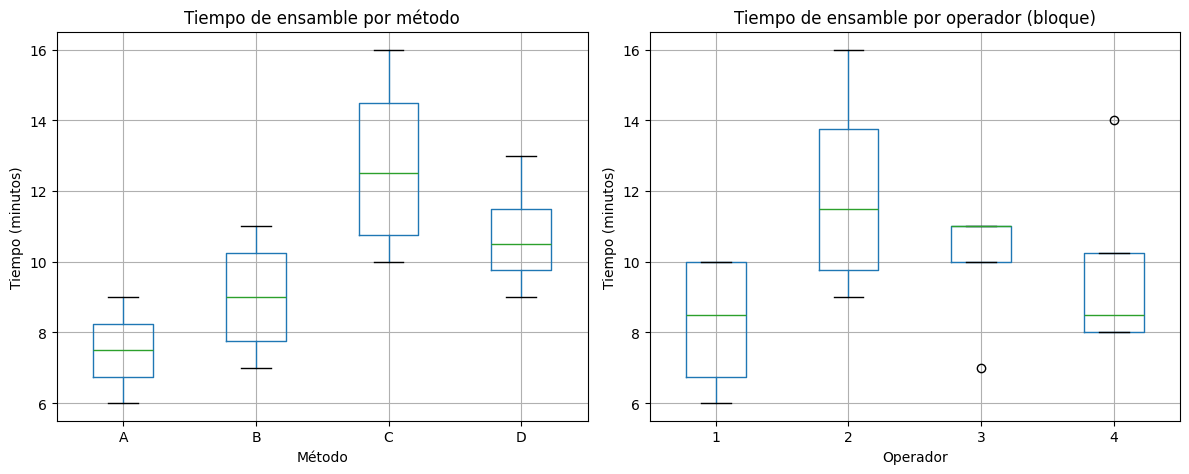

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datos.boxplot(column='tiempo', by='metodo', ax=axes[0])
axes[0].set_title('Tiempo de ensamble por método')
axes[0].set_xlabel('Método')
axes[0].set_ylabel('Tiempo (minutos)')

datos.boxplot(column='tiempo', by='operador', ax=axes[1])
axes[1].set_title('Tiempo de ensamble por operador (bloque)')
axes[1].set_xlabel('Operador')
axes[1].set_ylabel('Tiempo (minutos)')

plt.suptitle('')
plt.tight_layout()
plt.show()

***Nota**: Ya en los boxplots se nota que tanto el método como el operador parecen desplazar el tiempo de ensamble: el método C tiende a tardar más, y el operador 2 es sistemáticamente más lento que los demás. Esto último confirma que bloquear por operador es una buena decisión de diseño.*

## Gráfico de perfiles (revisión visual de aditividad)

Antes de ajustar el modelo, revisamos que el efecto del método sea razonablemente consistente entre operadores (líneas aproximadamente paralelas → aditividad razonable).

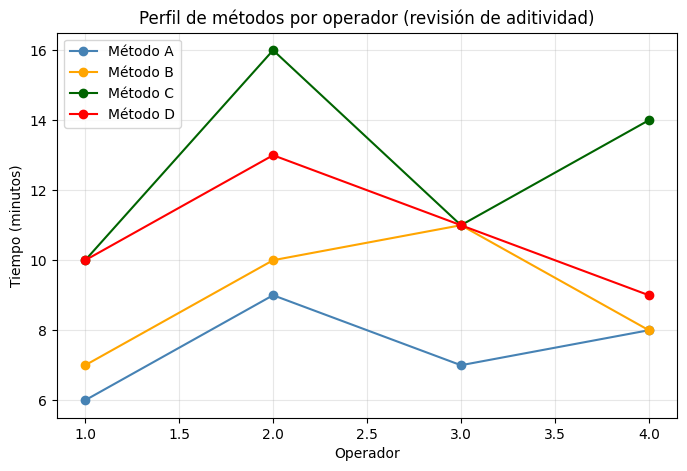

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colores = {'A': 'steelblue', 'B': 'orange', 'C': 'darkgreen', 'D': 'red'}

for m in datos['metodo'].cat.categories:
    sub = datos[datos['metodo'] == m]
    ax.plot(sub['operador'].astype(int), sub['tiempo'], 'o-', color=colores[m], label=f'Método {m}')

ax.set_xlabel('Operador')
ax.set_ylabel('Tiempo (minutos)')
ax.set_title('Perfil de métodos por operador (revisión de aditividad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## ANOVA para el DBCA

Ajustamos el modelo `tiempo ~ metodo + operador` (sin interacción, tal como exige el modelo aditivo del DBCA) y obtenemos la tabla ANOVA con suma de cuadrados tipo II.

In [ ]:
modelo_dbca = ols('tiempo ~ C(metodo) + C(operador)', data=datos).fit()
anova_dbca = sm.stats.anova_lm(modelo_dbca, typ=2)
print("=== TABLA ANOVA (DBCA) ===")
print(anova_dbca)

=== TABLA ANOVA (DBCA) ===
             sum_sq   df      F  PR(>F)
C(metodo)      61.5  3.0  10.25  0.0029
C(operador)    28.5  3.0   4.75  0.0298
Residual       18.0  9.0    NaN     NaN


**Lectura de la tabla:** el valor-p de `C(metodo)` es menor que 0.05, lo cual implica que se rechaza $H_0$ y se concluye que **al menos un método de ensamble difiere de los demás** en tiempo promedio. El valor-p de `C(operador)` es solo informativo: nos dice si el bloqueo por operador estaba justificado (confirma que había variabilidad real entre operadores que valía la pena controlar).

## ¿Qué hubiera pasado sin bloquear? Comparación contra un DCA

Para dimensionar el aporte del bloqueo, ajustamos también el modelo **ignorando el operador** (como si fuera un DCA de un solo factor) y comparamos el cuadrado medio del error de ambos modelos.


In [ ]:
modelo_dca = ols('tiempo ~ C(metodo)', data=datos).fit()
anova_dca = sm.stats.anova_lm(modelo_dca, typ=2)
print("=== TABLA ANOVA (DCA, ignorando el bloque) ===")
print(anova_dca)

CME_dbca = anova_dbca.loc['Residual', 'sum_sq'] / anova_dbca.loc['Residual', 'df']
CME_dca = anova_dca.loc['Residual', 'sum_sq'] / anova_dca.loc['Residual', 'df']

print(f"\nCME del DBCA (bloqueando por operador): {CME_dbca:.4f}")
print(f"CME del DCA  (sin bloquear):            {CME_dca:.4f}")
print(f"Reducción del error al bloquear: {(1 - CME_dbca/CME_dca)*100:.1f}%")


=== TABLA ANOVA (DCA, ignorando el bloque) ===
           sum_sq    df       F  PR(>F)
C(metodo)    61.5   3.0  5.2903  0.0148
Residual     46.5  12.0     NaN     NaN

CME del DBCA (bloqueando por operador): 2.0000
CME del DCA  (sin bloquear):            3.8750
Reducción del error al bloquear: 48.4%


## Verificación de supuestos sobre los residuos

Analizamos los residuos del modelo DBCA: normalidad (Q-Q plot + Shapiro-Wilk), homocedasticidad (residuos vs. ajustados + Levene) e independencia (se garantizó por diseño, al aleatorizar el orden de los métodos dentro de cada operador).

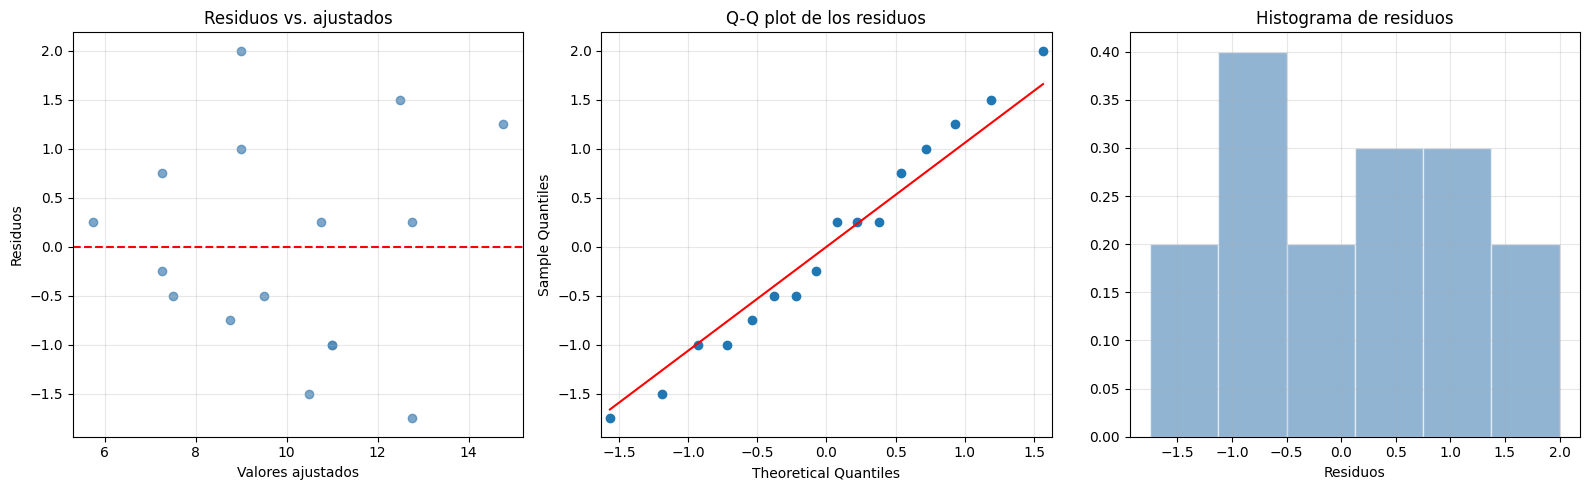

In [ ]:
residuos = modelo_dbca.resid
ajustados = modelo_dbca.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuos vs. ajustados (homocedasticidad)
axes[0].scatter(ajustados, residuos, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. ajustados')
axes[0].grid(True, alpha=0.3)

# Q-Q plot (normalidad)
sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')
axes[1].grid(True, alpha=0.3)

# Histograma
axes[2].hist(residuos, bins=6, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residuos')
axes[2].set_title('Histograma de residuos')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Prueba de normalidad de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print("=== PRUEBA DE SHAPIRO-WILK (normalidad) ===")
print(f"Estadístico W = {shapiro_stat:.4f}   valor-p = {shapiro_p:.4f}")
print("-> No se rechaza normalidad" if shapiro_p > 0.05 else "-> Se rechaza normalidad")

# Prueba de Levene (homogeneidad de varianzas entre métodos)
grupos = [g['tiempo'].values for _, g in datos.groupby('metodo', observed=True)]
levene_stat, levene_p = levene(*grupos)
print("\n=== PRUEBA DE LEVENE (homocedasticidad entre métodos) ===")
print(f"Estadístico = {levene_stat:.4f}   valor-p = {levene_p:.4f}")
print("-> No se rechaza homocedasticidad" if levene_p > 0.05 else "-> Se rechaza homocedasticidad")

=== PRUEBA DE SHAPIRO-WILK (normalidad) ===
Estadístico W = 0.9730   valor-p = 0.8844
-> No se rechaza normalidad

=== PRUEBA DE LEVENE (homocedasticidad entre métodos) ===
Estadístico = 1.8667   valor-p = 0.1890
-> No se rechaza homocedasticidad


## Comparaciones múltiples (LSD y Tukey HSD)

Como el ANOVA rechaza la igualdad de métodos, se necesita identificar **cuáles** métodos difieren entre sí. Se muestran dos procedimientos clásicos: la **Diferencia Mínima Significativa (LSD)** y la prueba de **Tukey HSD** (más conservadora, controla mejor el error tipo I al hacer comparaciones múltiples).

In [ ]:
# --- LSD ---
CME = anova_dbca.loc['Residual', 'sum_sq'] / anova_dbca.loc['Residual', 'df']
gl_error = anova_dbca.loc['Residual', 'df']
b = datos['operador'].nunique()  # número de bloques
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME / b)

print("=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.4f}   t_crítico(0.975, {gl_error:.0f}) = {t_critico:.4f}   LSD = {LSD:.4f}\n")

medias = datos.groupby('metodo', observed=True)['tiempo'].mean()
print("Diferencias significativas entre métodos (|diferencia| > LSD):")
metodos = list(medias.index)
for i, m1 in enumerate(metodos):
    for m2 in metodos[i+1:]:
        diff = medias[m1] - medias[m2]
        marca = "-> Diferente" if abs(diff) > LSD else ""
        print(f"  {m1} - {m2} = {diff:6.2f}   {marca}")


=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 2.0000   t_crítico(0.975, 9) = 2.2622   LSD = 2.2622

Diferencias significativas entre métodos (|diferencia| > LSD):
  A - B =  -1.50   
  A - C =  -5.25   -> Diferente
  A - D =  -3.25   -> Diferente
  B - C =  -3.75   -> Diferente
  B - D =  -1.75   
  C - D =   2.00   


=== TUKEY HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
---------------------------------------------------


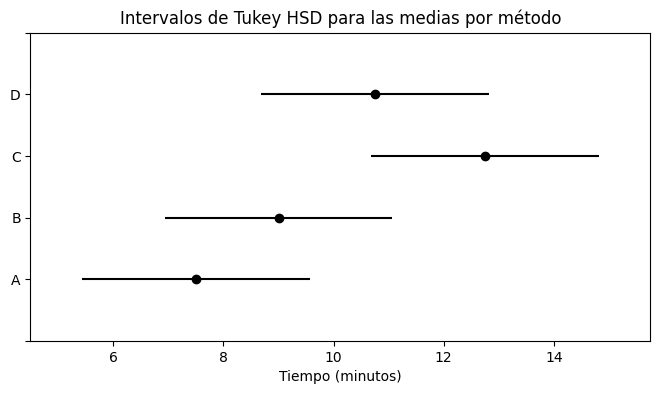

In [ ]:
# --- Tukey HSD ---
tukey = pairwise_tukeyhsd(datos['tiempo'], datos['metodo'], alpha=0.05)
print("=== TUKEY HSD ===")
print(tukey)

fig = tukey.plot_simultaneous(figsize=(8, 4))
plt.title('Intervalos de Tukey HSD para las medias por método')
plt.xlabel('Tiempo (minutos)')
plt.show()

## Gráfico de medias con intervalos de confianza

Una forma visual y directa de comunicar el resultado: las medias por método junto con su margen de error basado en el $CM_E$ del DBCA.

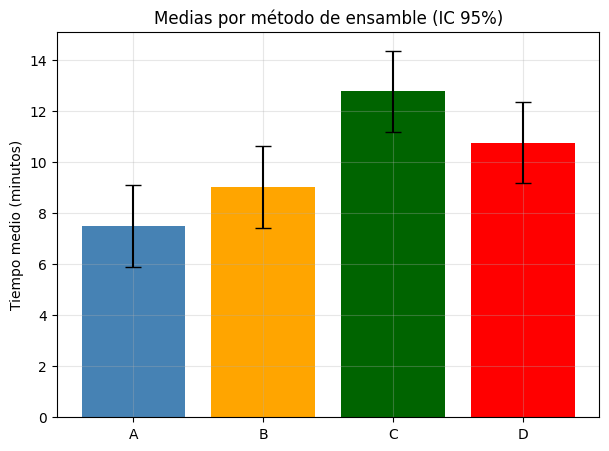

In [ ]:
errores = np.sqrt(CME / b) * t_critico

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(medias.index, medias.values, color=[colores[m] for m in medias.index])
ax.errorbar(medias.index, medias.values, yerr=errores, fmt='none', capsize=6, color='black')
ax.set_ylabel('Tiempo medio (minutos)')
ax.set_title('Medias por método de ensamble (IC 95%)')
ax.grid(True, alpha=0.3)
plt.show()

## ¿Valió la pena bloquear? Eficiencia relativa del ejemplo

In [ ]:
SC_bloque = anova_dbca.loc['C(operador)', 'sum_sq']
gl_bloque = anova_dbca.loc['C(operador)', 'df']
SC_error_dbca = anova_dbca.loc['Residual', 'sum_sq']
gl_error_dbca = anova_dbca.loc['Residual', 'df']

CME_dca_estimado = (SC_bloque + SC_error_dbca) / (gl_bloque + gl_error_dbca)
RE = CME_dca_estimado / CME_dbca

print(f"CM del error si NO se hubiera bloqueado (estimado): {CME_dca_estimado:.4f}")
print(f"CM del error del DBCA (bloqueando):                 {CME_dbca:.4f}")
print(f"Eficiencia relativa del bloqueo (RE): {RE:.2f}")
print(f"\nInterpretación: bloquear por operador equivale a tener que replicar un DCA "
      f"aproximadamente {RE:.1f} veces para lograr la misma precisión.")

CM del error si NO se hubiera bloqueado (estimado): 3.8750
CM del error del DBCA (bloqueando):                 2.0000
Eficiencia relativa del bloqueo (RE): 1.94

Interpretación: bloquear por operador equivale a tener que replicar un DCA aproximadamente 1.9 veces para lograr la misma precisión.


## Conclusiones del Ejemplo 1

Con los resultados obtenidos se puede concluir:

**1. Diferencias entre métodos de ensamble.** El ANOVA del DBCA da $F_{metodo}=10.25$ con $p=0.0029$ (< 0.05): se rechaza $H_0$ y se concluye que **el método de ensamble sí afecta el tiempo promedio**. El método **A** tiene la media más baja (7.50 min) y el **C** la más alta (12.75 min), con B (9.00) y D (10.75) en un punto intermedio.

**2. El bloqueo por operador estaba justificado.** El efecto de bloque también resulta significativo ($F_{operador}=4.75$, $p=0.0298$): había una diferencia real entre operadores (el operador 2 es notoriamente más lento, con media 12.00 min, frente a 8.25 min del operador 1).

**3. Ganancia de precisión al bloquear.** El $CM_E$ bajó de 3.875 (si se hubiera analizado como DCA, ignorando el operador) a 2.000 con el DBCA, es decir, una **reducción del error del 48.4%**. La eficiencia relativa es $RE = 1.94$: bloquear por operador equivale, en precisión, a haber duplicado casi el número de réplicas de un DCA sin bloque. **Bloquear fue una decisión de diseño acertada en reducción de costos por precisión.**

**4. Supuestos del modelo.** Los residuos no muestran evidencia de no-normalidad (Shapiro-Wilk $W=0.973$, $p=0.884$) ni de heterocedasticidad entre métodos (Levene $p=0.189$). Los tres supuestos clave (normalidad, homocedasticidad e independencia por diseño) se cumplen razonablemente, por lo que las pruebas F, LSD y Tukey son válidas.

**5. ¿Qué métodos difieren entre sí?**:

- **LSD** marca como diferentes A-C, A-D y B-C (todas las diferencias superan 2.26 minutos).
- **Tukey HSD** solo confirma como significativa la diferencia **A vs. C** ($\text{diferencia}=5.25$, $p=0.0123$); A-D y B-C, aunque marcadas por LSD, no sobreviven la corrección de Tukey ($p=0.144$ y $p=0.080$).


# Ejemplo aplicado 2: compuestos para reducir el consumo de gasolina

**Contexto.** Una asociación de consumidores quiere comprobar si ciertos compuestos reducen realmente el consumo de gasolina. Se usan **9 vehículos nuevos de distintas marcas con cilindrada similar**; con cada vehículo, un mismo conductor recorre un mismo trayecto **3 veces**, usando en cada recorrido un compuesto distinto.

| Elemento | Descripción |
|---|---|
| Variable respuesta | $Y_{ij}$ = consumo de gasolina (litros) del vehículo $j$ con el compuesto $i$ |
| Factor (tratamiento) | Compuesto de gasolina, 3 niveles: **A** = Cyber-gas, **B** = Consumin, **C** = sin aditivo |
| Unidades experimentales | Los vehículos |
| Bloques | Los 9 vehículos nuevos de distintas marcas |
| Tipo de bloque | **Aleatorio** — los vehículos se seleccionaron al azar |

Es un DBCA con $a=3$ tratamientos y $b=9$ bloques. Al revisar la información **no se pudo recuperar el dato correspondiente al compuesto B en el vehículo 8** — trabajaremos con ese dato faltante en la sección 4.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.libqsturng import qsturng
from scipy.stats import t, f, shapiro, levene

pd.set_option('display.precision', 4)
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
# Datos del experimento (consumo en litros). El compuesto B del vehículo 8 no se pudo recuperar.
vehiculo = list(range(1, 10))
comp_A = [15.5, 13.1, 12.2, 14.2, 14.0, 14.9, 12.0, 15.0, 12.4]
comp_B = [15.6, 13.0, 11.8, 15.0, 12.4, 14.7, 12.0, np.nan, 12.3]   # dato faltante en el vehículo 8
comp_C = [16.6, 13.5, 13.4, 14.8, 14.3, 15.6, 13.2, 14.9, 13.5]

# Nota: evitamos nombrar las variables A/B/C a secas, porque 'C' choca con
# la función C() que usan las fórmulas de statsmodels/patsy más adelante.
ancho = pd.DataFrame({'vehiculo': vehiculo, 'A': comp_A, 'B': comp_B, 'C': comp_C})
ancho

,vehiculo,A,B,C
0,1,15.5,15.6,16.6
1,2,13.1,13.0,13.5
2,3,12.2,11.8,13.4
3,4,14.2,15.0,14.8
4,5,14.0,12.4,14.3
5,6,14.9,14.7,15.6
6,7,12.0,12.0,13.2
7,8,15.0,NaN,14.9
8,9,12.4,12.3,13.5


## Un dato faltante: estimación por la fórmula de Yates

Fórmula para **estimar** el valor faltante de forma que la suma de cuadrados del error quede minimizada:

$$\hat{Y} = \omega = \frac{k\,Y^*_{B\cdot} + b\,Y^*_{\cdot 8} - Y^*_{\cdot\cdot}}{(k-1)(b-1)}$$

donde (usando un asterisco para indicar "sin contar el dato faltante"):

- $Y^*_{B\cdot}$: suma del tratamiento que tiene el dato faltante (aquí, compuesto B)
- $Y^*_{\cdot 8}$: suma del bloque que tiene el dato faltante (aquí, vehículo 8)
- $Y^*_{\cdot\cdot}$: suma total del experimento
- $k$: número de tratamientos, $b$: número de bloques


In [ ]:
k = 3   # número de tratamientos
b = 9   # número de bloques

Y_B_estrella = ancho['B'].sum()                                  # suma de B sin el dato faltante
Y_8_estrella = ancho.loc[ancho['vehiculo'] == 8, ['A', 'C']].sum(axis=1).values[0]  # suma del vehículo 8 sin el dato faltante
Y_total_estrella = ancho[['A', 'B', 'C']].sum().sum()             # suma total sin el dato faltante

print(f"Suma del tratamiento B (sin el dato faltante):  Y*_B. = {Y_B_estrella}")
print(f"Suma del bloque 8 (sin el dato faltante):        Y*_8. = {Y_8_estrella}")
print(f"Suma total (sin el dato faltante):               Y*..  = {Y_total_estrella}")

omega = (k * Y_B_estrella + b * Y_8_estrella - Y_total_estrella) / ((k - 1) * (b - 1))
print(f"\nValor estimado para el dato faltante (vehiculo 8, compuesto B):  Y_estimado = {omega:.2f}")

Suma del tratamiento B (sin el dato faltante):  Y*_B. = 106.8
Suma del bloque 8 (sin el dato faltante):        Y*_8. = 29.9
Suma total (sin el dato faltante):               Y*..  = 359.90000000000003

Valor estimado para el dato faltante (vehiculo 8, compuesto B):  Y_estimado = 14.35


In [ ]:
# Completamos la tabla con el valor estimado
datos = ancho.copy()
datos.loc[datos['vehiculo'] == 8, 'B'] = omega
datos

,vehiculo,A,B,C
0,1,15.5,15.60,16.6
1,2,13.1,13.00,13.5
2,3,12.2,11.80,13.4
3,4,14.2,15.00,14.8
4,5,14.0,12.40,14.3
5,6,14.9,14.70,15.6
6,7,12.0,12.00,13.2
7,8,15.0,14.35,14.9
8,9,12.4,12.30,13.5


## ANOVA con el dato estimado (ajuste de grados de libertad)

Con la tabla ya completa podemos calcular la ANOVA con las fórmulas normales del DBCA — **pero el grado de libertad del error debe reducirse en 1** por cada dato que se estimó, ya que esa celda no aporta información nueva independiente:

$$gl_{Error} = (a-1)(b-1) - (\text{número de datos estimados})$$

Aquí: $gl_{Error} = (3-1)(9-1) - 1 = 15$ .

In [ ]:
# Formato largo para trabajar con statsmodels y para los gráficos
largo = datos.melt(id_vars='vehiculo', value_vars=['A', 'B', 'C'],
                    var_name='compuesto', value_name='consumo')
largo['vehiculo'] = largo['vehiculo'].astype('category')
largo['compuesto'] = largo['compuesto'].astype('category')

print("=== MEDIAS POR COMPUESTO (TRATAMIENTO) ===")
print(largo.groupby('compuesto', observed=True)['consumo'].agg(['count', 'mean', 'std']))

=== MEDIAS POR COMPUESTO (TRATAMIENTO) ===
           count     mean     std
compuesto                        
A              9  13.7000  1.3181
B              9  13.4611  1.4512
C              9  14.4222  1.1595


In [ ]:
# Sumas de cuadrados calculadas "a mano" con las fórmulas del DBCA
Y_trat = datos[['A', 'B', 'C']].sum()                 # totales por tratamiento
Y_bloq = datos[['A', 'B', 'C']].sum(axis=1)           # totales por bloque
Y_total = datos[['A', 'B', 'C']].to_numpy().sum()
N = k * b
correccion = Y_total**2 / N

SCT = (datos[['A', 'B', 'C']].to_numpy()**2).sum() - correccion
SCTr = (Y_trat**2).sum() / b - correccion
SCB = (Y_bloq**2).sum() / k - correccion
SCE = SCT - SCTr - SCB

gl_trat = k - 1
gl_bloq = b - 1
gl_error = (k - 1) * (b - 1) - 1     # -1 porque se estimó un dato
gl_total = N - 1 - 1                 # -1 adicional por el mismo motivo

CMTr = SCTr / gl_trat
CMB = SCB / gl_bloq
CME = SCE / gl_error

F_trat = CMTr / CME
F_bloq = CMB / CME
p_trat = 1 - f.cdf(F_trat, gl_trat, gl_error)
p_bloq = 1 - f.cdf(F_bloq, gl_bloq, gl_error)

anova_manual = pd.DataFrame({
    'SC':  [SCTr, SCB, SCE, SCT],
    'gl':  [gl_trat, gl_bloq, gl_error, gl_total],
    'CM':  [CMTr, CMB, CME, np.nan],
    'F0':  [F_trat, F_bloq, np.nan, np.nan],
    'valor_p': [p_trat, p_bloq, np.nan, np.nan]
}, index=['Tratamientos (compuesto)', 'Bloques (vehículo)', 'Error', 'Total'])

print("=== TABLA ANOVA (dato faltante estimado, gl del error ajustado) ===")
anova_manual


=== TABLA ANOVA (dato faltante estimado, gl del error ajustado) ===


,SC,gl,CM,F0,valor_p
Tratamientos (compuesto),4.5072,2,2.2536,12.3774,6.6874e-04
Bloques (vehículo),38.7733,8,4.8467,26.6192,1.6187e-07
Error,2.7311,15,0.1821,NaN,NaN
Total,46.0117,25,NaN,NaN,NaN


In [ ]:
modelo = ols('consumo ~ C(compuesto) + C(vehiculo)', data=largo).fit()
anova_statsmodels = sm.stats.anova_lm(modelo, typ=2)
print("=== ANOVA vía statsmodels (gl del error SIN ajustar: 16) ===")
print(anova_statsmodels)

print(f"\nCME ajustado a mano (gl=15): {CME:.4f}")
print(f"CME sin ajustar (gl=16, statsmodels): "
      f"{anova_statsmodels.loc['Residual','sum_sq']/anova_statsmodels.loc['Residual','df']:.4f}")

=== ANOVA vía statsmodels (gl del error SIN ajustar: 16) ===
               sum_sq    df        F      PR(>F)
C(compuesto)   4.5072   2.0  13.2026  4.1078e-04
C(vehiculo)   38.7733   8.0  28.3938  4.8415e-08
Residual       2.7311  16.0      NaN         NaN

CME ajustado a mano (gl=15): 0.1821
CME sin ajustar (gl=16, statsmodels): 0.1707


**Conclusión de esta sección:** con $F_{compuesto}\approx 12.4$ y $gl=(2,15)$, el valor-p es muy pequeño (bien por debajo de 0.05): se rechaza $H_{0A}$ y se concluye que **el tipo de compuesto sí afecta el consumo promedio de gasolina**. El efecto de bloque (vehículo) también resulta significativo, lo que confirma que existía variabilidad real entre vehículos y que bloquear fue una decisión acertada.

## Verificación de supuestos

Trabajamos sobre los residuos del modelo ajustado con la tabla ya completada.


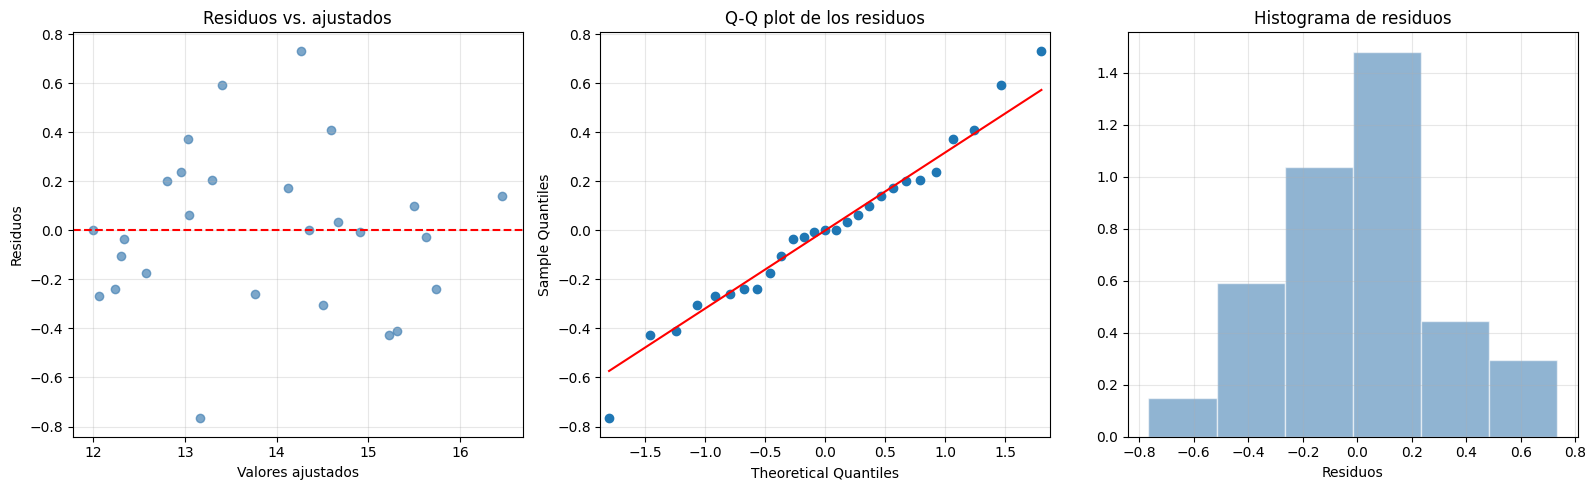

In [ ]:
residuos = modelo.resid
ajustados = modelo.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(ajustados, residuos, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. ajustados')
axes[0].grid(True, alpha=0.3)

sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Q-Q plot de los residuos')
axes[1].grid(True, alpha=0.3)

axes[2].hist(residuos, bins=6, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[2].set_xlabel('Residuos')
axes[2].set_title('Histograma de residuos')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
shapiro_stat, shapiro_p = shapiro(residuos)
print("=== PRUEBA DE SHAPIRO-WILK (normalidad) ===")
print(f"W = {shapiro_stat:.4f}   valor-p = {shapiro_p:.4f}")
print("-> No se rechaza normalidad" if shapiro_p > 0.05 else "-> Se rechaza normalidad")

grupos = [g['consumo'].values for _, g in largo.groupby('compuesto', observed=True)]
levene_stat, levene_p = levene(*grupos)
print("\n=== PRUEBA DE LEVENE (homocedasticidad entre compuestos) ===")
print(f"Estadístico = {levene_stat:.4f}   valor-p = {levene_p:.4f}")
print("-> No se rechaza homocedasticidad" if levene_p > 0.05 else "-> Se rechaza homocedasticidad")

=== PRUEBA DE SHAPIRO-WILK (normalidad) ===
W = 0.9847   valor-p = 0.9501
-> No se rechaza normalidad

=== PRUEBA DE LEVENE (homocedasticidad entre compuestos) ===
Estadístico = 0.4534   valor-p = 0.6408
-> No se rechaza homocedasticidad


## Comparaciones múltiples (LSD y Tukey)

Calculamos LSD y Tukey HSD con las fórmulas estándar, usando el $CM_E$ y los grados de libertad **ya ajustados** por el dato estimado ($CM_E=0.1821$, $gl=15$).

In [ ]:
# --- LSD ---
t_critico = t.ppf(0.975, gl_error)
LSD = t_critico * np.sqrt(2 * CME / b)

print("=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.4f}   t_crítico(0.975, {gl_error}) = {t_critico:.4f}   LSD = {LSD:.4f}\n")

medias = largo.groupby('compuesto', observed=True)['consumo'].mean()
compuestos = list(medias.index)
print("Diferencias entre compuestos (|diferencia| > LSD -> significativa):")
for i, m1 in enumerate(compuestos):
    for m2 in compuestos[i+1:]:
        diff = medias[m1] - medias[m2]
        marca = "-> Diferente" if abs(diff) > LSD else ""
        print(f"  {m1} - {m2} = {diff:6.2f}   {marca}")

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 0.1821   t_crítico(0.975, 15) = 2.1314   LSD = 0.4287

Diferencias entre compuestos (|diferencia| > LSD -> significativa):
  A - B =   0.24   
  A - C =  -0.72   -> Diferente
  B - C =  -0.96   -> Diferente


In [ ]:
# --- Tukey HSD (usando el CME y gl ajustados) ---
q_critico = qsturng(0.95, k, gl_error)
HSD = q_critico * np.sqrt(CME / b)

print("=== COMPARACIONES MÚLTIPLES (TUKEY HSD) ===")
print(f"q_crítico(0.05, k={k}, gl={gl_error}) = {q_critico:.4f}   HSD = {HSD:.4f}\n")

print("Diferencias entre compuestos (|diferencia| > HSD -> significativa):")
for i, m1 in enumerate(compuestos):
    for m2 in compuestos[i+1:]:
        diff = medias[m1] - medias[m2]
        marca = "-> Diferente" if abs(diff) > HSD else ""
        print(f"  {m1} - {m2} = {diff:6.2f}   {marca}")


=== COMPARACIONES MÚLTIPLES (TUKEY HSD) ===
q_crítico(0.05, k=3, gl=15) = 3.6719   HSD = 0.5223

Diferencias entre compuestos (|diferencia| > HSD -> significativa):
  A - B =   0.24   
  A - C =  -0.72   -> Diferente
  B - C =  -0.96   -> Diferente


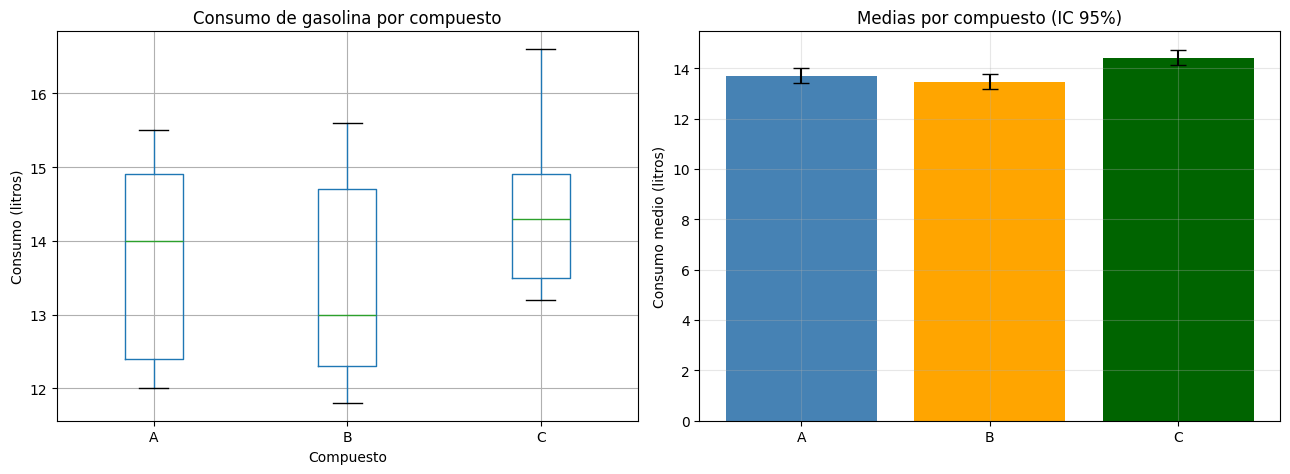

In [ ]:
# Gráfico de medias con IC 95% (usando el CME ajustado)
errores = np.sqrt(CME / b) * t_critico
colores = {'A': 'steelblue', 'B': 'orange', 'C': 'darkgreen'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

largo.boxplot(column='consumo', by='compuesto', ax=axes[0])
axes[0].set_title('Consumo de gasolina por compuesto')
axes[0].set_xlabel('Compuesto')
axes[0].set_ylabel('Consumo (litros)')

axes[1].bar(medias.index, medias.values, color=[colores[m] for m in medias.index])
axes[1].errorbar(medias.index, medias.values, yerr=errores, fmt='none', capsize=6, color='black')
axes[1].set_ylabel('Consumo medio (litros)')
axes[1].set_title('Medias por compuesto (IC 95%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

## Conclusiones

Con los resultados que obtuviste al ejecutar el notebook:

**1. Diferencias entre compuestos.** El ANOVA (con el grado de libertad del error ya ajustado por el dato estimado) da $F_{compuesto}=12.38$ con $gl=(2,15)$ y $p=0.00067$ (< 0.05): se rechaza $H_{0A}$ y se concluye que **el compuesto de gasolina sí afecta el consumo promedio**. Las medias fueron: **B = 13.46 L** (la más baja), **A = 13.70 L**, **C = 14.42 L** (la más alta).

**2. El bloqueo por vehículo estaba justificado.** El efecto de bloque también es altamente significativo ($F_{vehículo}=26.62$, $p=1.6\times10^{-7}$): había variabilidad real entre vehículos (marcas distintas, aun con cilindrada similar) que habría inflado el error si no se hubiera controlado. Bloquear por vehículo fue una buena decisión de diseño.

**3. El dato faltante se recuperó sin perder el experimento.** La fórmula de Yates estimó el consumo faltante del vehículo 8 con compuesto B en **14.35 L**, un valor coherente con el resto de los datos de ese vehículo y ese compuesto. El costo fue perder 1 grado de libertad del error (quedó en 15 en vez de 16); comparando con el ANOVA "ingenuo" de `statsmodels` (que no sabe que hay un dato estimado y usa $gl=16$), la suma de cuadrados es idéntica pero el $CM_E$ cambia ligeramente (0.1821 vs. 0.1707) — la versión con el ajuste correcto es la que se debe reportar.

**4. Supuestos del modelo.** Los residuos no muestran evidencia de no-normalidad (Shapiro-Wilk $W=0.985$, $p=0.950$) ni de heterocedasticidad entre compuestos (Levene $p=0.641$): ambos supuestos se cumplen con holgura, así que las pruebas F, LSD y Tukey son válidas.

**5. ¿Qué compuestos difieren entre sí?** Con la fórmula estándar (advertencia de la sección 7: sin la corrección adicional de Cochran & Cox para el dato estimado), **tanto LSD (umbral 0.4287) como Tukey HSD (umbral 0.5223) coinciden** en que:

- **A vs. C** (diferencia de 0.72 L) → significativa
- **B vs. C** (diferencia de 0.96 L) → significativa
- **A vs. B** (diferencia de 0.24 L) → **no** significativa

Es decir, en este caso LSD y Tukey llegan a la **misma conclusión cualitativa** (a diferencia del ejemplo de métodos de ensamble del primer notebook, donde discrepaban): el compuesto **C se distingue claramente de A y de B** por tener mayor consumo, mientras que A y B no se logran diferenciar estadísticamente entre sí con este tamaño de muestra.

**Recomendación práctica:** evitar el compuesto **C** (sin aditivo), que muestra el mayor consumo promedio. Entre **A** (Cyber-gas) y **B** (Consumin) no hay evidencia suficiente para preferir uno sobre otro — numéricamente B es el más bajo (13.46 L), pero la diferencia con A no es estadísticamente significativa, por lo que ambos son alternativas razonables frente a no usar aditivo.